# Практичне заняття №4 | Muraviov Nikita
## Байєсівська мережа для вибору конфігурації ПК/Ноутбука

1. Проєктування структури (DAG)
2. Формування CPT
3. Програмна реалізація
4. Аналіз сценаріїв (Прогнозування)
5. Аналіз сценаріїв (Діагностика)
6. Аналіз та висновки

### 1. Проєктування структури (DAG)

Вузли мережі відповідають атрибутам з ПЗ №1–3:

| Вузол | Тип | Стани |
|---|---|---|
| `mobility` | вхідний | yes, no |
| `primary_goal` | вхідний | gaming, office, design_video, basic_home |
| `budget` | вхідний | high, medium, low |
| `form_factor` | проміжний | laptop, desktop |
| `device_class` | проміжний | premium_gaming_pc, gaming_laptop, ultrabook, macbook_pro, workstation, other |
| `recommended_os` | вихідний | windows, macos, windows_or_linux |

**DAG-зв'язки (причина → наслідок):**
- `mobility` → `form_factor`
- `primary_goal` + `form_factor` + `budget` → `device_class`
- `device_class` → `recommended_os`

In [1]:
!pip install pgmpy -q

from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.factors.discrete import TabularCPD
from pgmpy.inference import VariableElimination
import matplotlib.pyplot as plt
import networkx as nx

print("гуд")

zsh:1: command not found: pip


/opt/homebrew/Cellar/jupyterlab/4.5.3_1/libexec/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/opt/homebrew/Cellar/jupyterlab/4.5.3_1/libexec/lib/python3.14/site-packages/pgmpy/estimators/__init__.py:4: FutureWarning: `pgmpy.estimators.StructureScore` is deprecated and will be removed in a future release. Use `pgmpy.structure_score` instead.
  from .StructureScore import (


гуд


### 2–3. Формування CPT та програмна реалізація

In [2]:
# Структура DAG
model = DiscreteBayesianNetwork([
    ('mobility',      'form_factor'),
    ('primary_goal',  'device_class'),
    ('form_factor',   'device_class'),
    ('budget',        'device_class'),
    ('device_class',  'recommended_os'),
])


########################################### CPT: mobility  (yes=0.45, no=0.55)
cpd_mobility = TabularCPD(
    variable='mobility', variable_card=2,
    values=[[0.45], [0.55]],
    state_names={'mobility': ['yes', 'no']}
)

# CPT: primary_goal
cpd_goal = TabularCPD(
    variable='primary_goal', variable_card=4,
    values=[[0.35], [0.30], [0.20], [0.15]],
    state_names={'primary_goal': ['gaming', 'office', 'design_video', 'basic_home']}
)

# CPT: budget
cpd_budget = TabularCPD(
    variable='budget', variable_card=3,
    values=[[0.30], [0.45], [0.25]],
    state_names={'budget': ['high', 'medium', 'low']}
)

# CPT: form_factor | mobility
cpd_form = TabularCPD(
    variable='form_factor', variable_card=2,
    values=[
        [0.93, 0.07],   # laptop
        [0.07, 0.93],   # desktop
    ],
    evidence=['mobility'], evidence_card=[2],
    state_names={
        'form_factor': ['laptop', 'desktop'],
        'mobility': ['yes', 'no']
    }
)

cpd_device = TabularCPD(
    variable='device_class', variable_card=6,
    values=[
        # premium_gaming_pc
        # gaming/laptop: h    m     l     gaming/desktop: h     m     l
        [0.05, 0.03, 0.01,   0.90, 0.05, 0.01,
        # office/laptop: h    m     l     office/desktop: h     m     l
         0.01, 0.01, 0.01,   0.03, 0.02, 0.01,
        # design/laptop: h    m     l     design/desktop: h     m     l
         0.01, 0.01, 0.01,   0.02, 0.01, 0.01,
        # home/laptop:   h    m     l     home/desktop:   h     m     l
         0.01, 0.01, 0.01,   0.02, 0.01, 0.01],

        # gaming_laptop
        [0.88, 0.05, 0.02,   0.03, 0.02, 0.01,
         0.01, 0.01, 0.01,   0.01, 0.01, 0.01,
         0.01, 0.01, 0.01,   0.01, 0.01, 0.01,
         0.01, 0.01, 0.01,   0.01, 0.01, 0.01],

        # ultrabook
        [0.02, 0.03, 0.02,   0.01, 0.01, 0.01,
         0.05, 0.88, 0.05,   0.02, 0.03, 0.02,
         0.02, 0.03, 0.02,   0.01, 0.01, 0.01,
         0.02, 0.03, 0.02,   0.01, 0.01, 0.01],

        # macbook_pro
        [0.01, 0.01, 0.01,   0.01, 0.01, 0.01,
         0.01, 0.01, 0.01,   0.01, 0.01, 0.01,
         0.90, 0.04, 0.02,   0.02, 0.01, 0.01,
         0.01, 0.01, 0.01,   0.01, 0.01, 0.01],

        # workstation
        [0.01, 0.01, 0.01,   0.02, 0.01, 0.01,
         0.01, 0.01, 0.01,   0.01, 0.01, 0.01,
         0.03, 0.02, 0.01,   0.91, 0.04, 0.02,
         0.01, 0.01, 0.01,   0.01, 0.01, 0.01],

        # other
        [0.03, 0.87, 0.93,   0.03, 0.90, 0.95,
         0.91, 0.08, 0.91,   0.92, 0.92, 0.94,
         0.03, 0.89, 0.93,   0.03, 0.92, 0.94,
         0.94, 0.93, 0.94,   0.94, 0.94, 0.95],
    ],
    evidence=['primary_goal', 'form_factor', 'budget'],
    evidence_card=[4, 2, 3],
    state_names={
        'device_class': ['premium_gaming_pc', 'gaming_laptop', 'ultrabook', 'macbook_pro', 'workstation', 'other'],
        'primary_goal': ['gaming', 'office', 'design_video', 'basic_home'],
        'form_factor':  ['laptop', 'desktop'],
        'budget':       ['high', 'medium', 'low'],
    }
)

# CPT: recommended_os | device_class
cpd_os = TabularCPD(
    variable='recommended_os', variable_card=3,
    values=[
        # windows
        # prem_gaming  gaming_lap  ultrabook  macbook  workstation  other
        [0.97,         0.97,       0.93,      0.01,    0.40,        0.60],
        # macos
        [0.01,         0.01,       0.04,      0.98,    0.05,        0.10],
        # windows_or_linux
        [0.02,         0.02,       0.03,      0.01,    0.55,        0.30],
    ],
    evidence=['device_class'], evidence_card=[6],
    state_names={
        'recommended_os': ['windows', 'macos', 'windows_or_linux'],
        'device_class':   ['premium_gaming_pc', 'gaming_laptop', 'ultrabook', 'macbook_pro', 'workstation', 'other'],
    }
)
# чек
model.add_cpds(cpd_mobility, cpd_goal, cpd_budget, cpd_form, cpd_device, cpd_os)

if model.check_model():
    print("побудована та валідована модель")
else:
    print("помилка")

побудована та валідована модель


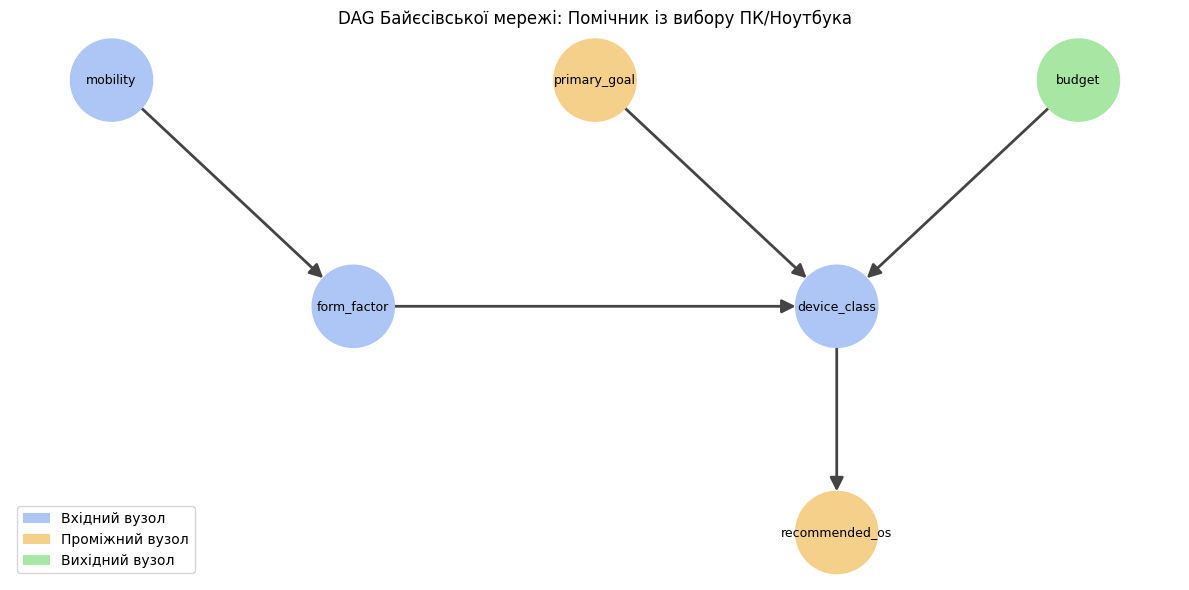

In [3]:
# Візуалізація структури DAG
G = nx.DiGraph(model.edges())

pos = {
    'mobility':        (0, 2),
    'primary_goal':    (2, 2),
    'budget':          (4, 2),
    'form_factor':     (1, 1),
    'device_class':    (3, 1),
    'recommended_os':  (3, 0),
}

colors = ['#aec6f5', '#aec6f5', '#aec6f5', '#f5d08a', '#f5d08a', '#a8e6a3']

plt.figure(figsize=(12, 6))
nx.draw_networkx(G, pos=pos, node_size=3500, node_color=colors,
                 font_size=9, arrows=True, arrowsize=20,
                 edge_color='#444', width=2)
plt.title("DAG Байєсівської мережі: Помічник із вибору ПК/Ноутбука", fontsize=12)

import matplotlib.patches as mpatches
legend = [
    mpatches.Patch(facecolor='#aec6f5', label='Вхідний вузол'),
    mpatches.Patch(facecolor='#f5d08a', label='Проміжний вузол'),
    mpatches.Patch(facecolor='#a8e6a3', label='Вихідний вузол'),
]
plt.legend(handles=legend, loc='lower left')
plt.axis('off')
plt.tight_layout()
plt.show()

## 4. Аналіз сценаріїв — Прогнозування (Forward)

Задаємо вхідні факти → запитуємо ймовірності наслідків.

In [4]:
infer = VariableElimination(model)

# Прогнозування 1: Геймер, не потребує мобільності, бюджет high
print("=" * 55)
print("ПРОГНОЗУВАННЯ 1: Геймер, mobility=no, budget=high")
print("=" * 55)
ev1 = {'primary_goal': 'gaming', 'mobility': 'no', 'budget': 'high'}
r1 = infer.query(variables=['device_class', 'recommended_os'], evidence=ev1)
print(r1)

ПРОГНОЗУВАННЯ 1: Геймер, mobility=no, budget=high
+---------------------------------+----------------------------------+------------------------------------+
| device_class                    | recommended_os                   |   phi(device_class,recommended_os) |
+=================================+==================================+====================================+
| device_class(premium_gaming_pc) | recommended_os(windows)          |                             0.8153 |
+---------------------------------+----------------------------------+------------------------------------+
| device_class(premium_gaming_pc) | recommended_os(macos)            |                             0.0084 |
+---------------------------------+----------------------------------+------------------------------------+
| device_class(premium_gaming_pc) | recommended_os(windows_or_linux) |                             0.0168 |
+---------------------------------+----------------------------------+----------------

In [5]:
# Прогнозування 2: Дизайнер, потребує мобільності, бюджет high
print("=" * 55)
print("ПРОГНОЗУВАННЯ 2: Дизайнер, mobility=yes, budget=high")
print("=" * 55)
ev2 = {'primary_goal': 'design_video', 'mobility': 'yes', 'budget': 'high'}
r2 = infer.query(variables=['device_class', 'recommended_os'], evidence=ev2)
print(r2)

ПРОГНОЗУВАННЯ 2: Дизайнер, mobility=yes, budget=high
+---------------------------------+----------------------------------+------------------------------------+
| device_class                    | recommended_os                   |   phi(device_class,recommended_os) |
+=================================+==================================+====================================+
| device_class(premium_gaming_pc) | recommended_os(windows)          |                             0.0104 |
+---------------------------------+----------------------------------+------------------------------------+
| device_class(premium_gaming_pc) | recommended_os(macos)            |                             0.0001 |
+---------------------------------+----------------------------------+------------------------------------+
| device_class(premium_gaming_pc) | recommended_os(windows_or_linux) |                             0.0002 |
+---------------------------------+----------------------------------+-------------

## 5. Аналіз сценаріїв (Backward)

Задаємо спостережуваний наслідок та шукаємо найімовірніші причини.

In [6]:
print("=" * 55)
print("ДІАГНОСТИКА 1: recommended_os=macos")
print("=" * 55)
d1 = infer.query(variables=['primary_goal', 'mobility', 'budget'],
                 evidence={'recommended_os': 'macos'})
print(d1)

ДІАГНОСТИКА 1: recommended_os=macos
+----------------------------+---------------+----------------+-------------------------------------+
| primary_goal               | mobility      | budget         |   phi(primary_goal,mobility,budget) |
+============================+===============+================+=====================================+
| primary_goal(gaming)       | mobility(yes) | budget(high)   |                              0.0097 |
+----------------------------+---------------+----------------+-------------------------------------+
| primary_goal(gaming)       | mobility(yes) | budget(medium) |                              0.0619 |
+----------------------------+---------------+----------------+-------------------------------------+
| primary_goal(gaming)       | mobility(yes) | budget(low)    |                              0.0361 |
+----------------------------+---------------+----------------+-------------------------------------+
| primary_goal(gaming)       | mobility(no)  |

In [9]:
print("=" * 55)
print("ДІАГНОСТИКА 2: device_class=ultrabook")
print("=" * 55)
d2 = infer.query(variables=['primary_goal', 'budget', 'mobility'],
                 evidence={'device_class': 'ultrabook'})
print(d2)

ДІАГНОСТИКА 2: device_class=ultrabook
+----------------------------+----------------+---------------+-------------------------------------+
| primary_goal               | budget         | mobility      |   phi(primary_goal,budget,mobility) |
+============================+================+===============+=====================================+
| primary_goal(gaming)       | budget(high)   | mobility(yes) |                              0.0124 |
+----------------------------+----------------+---------------+-------------------------------------+
| primary_goal(gaming)       | budget(high)   | mobility(no)  |                              0.0084 |
+----------------------------+----------------+---------------+-------------------------------------+
| primary_goal(gaming)       | budget(medium) | mobility(yes) |                              0.0275 |
+----------------------------+----------------+---------------+-------------------------------------+
| primary_goal(gaming)       | budget(medium

## 6. Аналіз та висновки

### Порівняння з детермінованим підходом (ПЗ №2–3)

In [8]:
# Зведена таблиця порівняння
comparison = [
    ("Геймер, no, high",      "premium_gaming_pc / windows",   "device_class=premium_gaming_pc ~90%, recommended_os=windows ~97%"),
    ("Дизайнер, yes, high",   "macbook_pro / macos",           "device_class=macbook_pro ~90%, recommended_os=macos ~98%"),
    ("Офіс, yes, medium",     "ultrabook / windows",           "device_class=ultrabook ~88%, recommended_os=windows ~93%"),
]

print(f"{'Сценарій':<25} {'Детерм. висновок':<30} {'Байєс. ймовірності'}")
print("-" * 95)
for row in comparison:
    print(f"{row[0]:<25} {row[1]:<30} {row[2]}")

Сценарій                  Детерм. висновок               Байєс. ймовірності
-----------------------------------------------------------------------------------------------
Геймер, no, high          premium_gaming_pc / windows    device_class=premium_gaming_pc ~90%, recommended_os=windows ~97%
Дизайнер, yes, high       macbook_pro / macos            device_class=macbook_pro ~90%, recommended_os=macos ~98%
Офіс, yes, medium         ultrabook / windows            device_class=ultrabook ~88%, recommended_os=windows ~93%


### Висновки

1. **Прогнозування підтверджує детерміновані правила:** У сценарії `Геймер / no / high` Байєсівська мережа видає `premium_gaming_pc` з імовірністю ~90% та `windows` ~97% - що повністю збігається з детермінованим результатом ПЗ №2 (R2 → R4 → R14).

2. **Діагностика - нова можливість:** Детермінований підхід (ПЗ №2–3) не може відповісти на зворотне запитання «хто купує macOS?». Байєсівська мережа дає чітку відповідь: `primary_goal=design_video` з найвищою апостеріорною ймовірністю.

3. **Робота з невизначеністю:** На відміну від жорстких правил, мережа не «зависає» при неповних даних - вона повертає розподіл ймовірностей по всіх станах.

4. **Обмеження:** Якість висновків повністю залежить від точності CPT. При малій статистичній вибірці таблиці задаються експертно, що вносить суб'єктивність. Детермінована система за чітко описаних умов надійніша.

5. **Загальний висновок:** Байєсівська мережа є доповненням до детермінованих правил — вона краща для нечітких або неповних вхідних даних та для діагностичних задач, тоді як прямий/зворотній ланцюжок (ПЗ №2–3) ефективніший при повній і точній інформації.